<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/project_store_sales_analysis/store_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Store Sales Analysis

###Incoming dataset (data)

In [43]:
# Запусти цей блок, щоб отримати датасет
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories = ['Молочне', 'Хліб та випічка', 'М\'ясо та риба', 'Овочі та фрукти', 'Напої']
products = {
    'Молочне':          ['Молоко 1л', 'Кефір 0.5л', 'Сир кисломолочний', 'Масло вершкове', 'Йогурт'],
    'Хліб та випічка':  ['Хліб білий', 'Батон', 'Булочка', 'Хліб житній', 'Круасан'],
    'М\'ясо та риба':   ['Куряче філе', 'Свинина', 'Ковбаса', 'Риба хек', 'Сосиски'],
    'Овочі та фрукти':  ['Картопля', 'Морква', 'Яблука', 'Банани', 'Помідори'],
    'Напої':            ['Вода 1.5л', 'Сік апельсиновий', 'Чай', 'Кава мелена', 'Лимонад'],
}
prices = {
    'Молоко 1л': 38, 'Кефір 0.5л': 22, 'Сир кисломолочний': 55, 'Масло вершкове': 95, 'Йогурт': 30,
    'Хліб білий': 28, 'Батон': 25, 'Булочка': 12, 'Хліб житній': 32, 'Круасан': 18,
    'Куряче філе': 165, 'Свинина': 210, 'Ковбаса': 145, 'Риба хек': 120, 'Сосиски': 98,
    'Картопля': 20, 'Морква': 15, 'Яблука': 45, 'Банани': 52, 'Помідори': 60,
    'Вода 1.5л': 18, 'Сік апельсиновий': 68, 'Чай': 85, 'Кава мелена': 155, 'Лимонад': 35,
}

chosen_cats = np.random.choice(categories, n, p=[0.25, 0.20, 0.20, 0.20, 0.15])
chosen_products = [np.random.choice(products[c]) for c in chosen_cats]

df_origin = pd.DataFrame({
    'transaction_id': range(1001, 1001 + n),
    'date':           pd.to_datetime(
                          np.random.choice(pd.date_range('2024-03-01', '2024-03-31'), n)
                      ),
    'hour':           np.random.choice(range(8, 21), n, p=[0.04,0.06,0.08,0.10,0.12,0.12,0.11,0.10,0.09,0.08,0.06,0.04,0.00]),
    'category':       chosen_cats,
    'product':        chosen_products,
    'quantity':       np.random.randint(1, 6, n),
    'price_uah':      [prices[p] for p in chosen_products],
    'customer_age':   np.random.randint(18, 70, n),
    'payment':        np.random.choice(['Готівка', 'Картка', 'Телефон'], n, p=[0.35, 0.50, 0.15]),
})


In [44]:
df = df_origin.copy()

In [45]:
df

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
...,...,...,...,...,...,...,...,...,...
295,1296,2024-03-08,10,М'ясо та риба,Сосиски,4,98,48,Готівка
296,1297,2024-03-05,13,Овочі та фрукти,Морква,5,15,28,Телефон
297,1298,2024-03-04,11,Молочне,Молоко 1л,3,38,27,Картка
298,1299,2024-03-24,14,М'ясо та риба,Ковбаса,1,145,20,Готівка


#Блок 1 - Перше знайомство з даними

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    int64         
 1   date            300 non-null    datetime64[ns]
 2   hour            300 non-null    int64         
 3   category        300 non-null    object        
 4   product         300 non-null    object        
 5   quantity        300 non-null    int64         
 6   price_uah       300 non-null    int64         
 7   customer_age    300 non-null    int64         
 8   payment         300 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 21.2+ KB


In [47]:
df['total_uah'] = df.quantity * df.price_uah
df['total_uah']

,total_uah
0,72
1,465
2,45
3,360
4,150
...,...
295,392
296,75
297,114
298,145


1. Виведи перші 7 рядків датафрейму.

In [48]:
print(df.head(7))

   transaction_id       date  hour         category         product  quantity  \
0            1001 2024-03-17    17  Хліб та випічка         Круасан         4   
1            1002 2024-03-13    14            Напої     Кава мелена         3   
2            1003 2024-03-01    18  Овочі та фрукти          Яблука         1   
3            1004 2024-03-02     8    М'ясо та риба        Риба хек         3   
4            1005 2024-03-09    19          Молочне          Йогурт         5   
5            1006 2024-03-03    13          Молочне      Кефір 0.5л         3   
6            1007 2024-03-31    15          Молочне  Масло вершкове         2   

   price_uah  customer_age  payment  total_uah  
0         18            28  Готівка         72  
1        155            40   Картка        465  
2         45            43   Картка         45  
3        120            51  Готівка        360  
4         30            63   Картка        150  
5         22            51   Картка         66  
6       

In [49]:
df.head(7) #display(df.head(7))

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка,72
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка,465
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка,45
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка,360
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка,150
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка,66
6,1007,2024-03-31,15,Молочне,Масло вершкове,2,95,46,Телефон,190


In [50]:
df.dtypes

,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


Дізнайся розмір таблиці (рядки × стовпці).

In [51]:
print(f"Size: {df.shape[0]} rows x {df.shape[1]} columns")

Size: 300 rows x 10 columns


Виведи типи даних кожного стовпця.

In [52]:
print("Data type:")
df.dtypes

Data type:


,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


Перевір, чи є пропущені значення.

In [53]:
df.isnull()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False


In [54]:
df.isna()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False


In [55]:
df.isnull().sum()

,0
transaction_id,0
date,0
hour,0
category,0
product,0
quantity,0
price_uah,0
customer_age,0
payment,0
total_uah,0


In [56]:
print(f"Missing data by columns:\n\n{df.isnull().sum()}")

Missing data by columns:

transaction_id    0
date              0
hour              0
category          0
product           0
quantity          0
price_uah         0
customer_age      0
payment           0
total_uah         0
dtype: int64


Виведи основну статистику (describe) для числових стовпців.

In [57]:
print("Statistics:\n")
df.describe().round(2)

Statistics:



,transaction_id,date,hour,quantity,price_uah,customer_age,total_uah
count,300.00,300,300.00,300.00,300.00,300.0,300.00
mean,1150.50,2024-03-16 02:14:24,13.72,2.97,63.45,43.0,186.97
min,1001.00,2024-03-01 00:00:00,8.00,1.00,12.00,18.0,12.00
25%,1075.75,2024-03-08 00:00:00,12.00,2.00,22.00,31.0,60.00
50%,1150.50,2024-03-16 12:00:00,14.00,3.00,38.00,42.5,120.00
75%,1225.25,2024-03-24 00:00:00,16.00,4.00,95.75,55.0,256.25
max,1300.00,2024-03-31 00:00:00,19.00,5.00,210.00,69.0,840.00
std,86.75,NaN,2.74,1.44,51.68,14.6,180.27


#The conclusion:

This dataset consists of about 300 transactions, 10 columns, no values are omitted.

The average check is 186.97 UAH.   
The minimum check -  12.00 UAH.
The maximum check - 840.00 UAH.  
No suspicious data found.  


"""
[1, 7, 9, 10, 12, 15]
Медиана: (9 + 10) / 2 = 9.5

[1, 7, 9, 10, 12, 15, 20]
M = 10

[1, 7, 9, 10, 12, 15, 20]
M = 10 - 50%
min = 1
max = 20
count = 7 mean = 10.57

In [58]:
s = [1, 7, 9, 10, 12, 15, 20]
mean = sum(s) / len(s)
mean

10.571428571428571

In [59]:
s = [1, 1, 1, 1, 1, 1, 1000]
mean = sum(s) / len(s)
mean

143.71428571428572

###### Mediana


```
[1, 7, 9, 10, 12, 15]
```
Медіана: (9 + 10) / 2 = 9,5
```
[1, 7, 9, 10, 12, 15, 20]
```
Медіана: 10
```
[1, 7, 9, 10, 12, 15, 20]
```
Медіана: 10 - `50%`  
`min` = 1  
`max` = 20  
`count` = 7  
`mean` = 10.57  
`25%` ->  
0% - min -> 25% -> 50% - median -> 75% -> 100% - max
std ->  
10.57 - 1 = 9.57
10.57 - 7 = 3.57
..
20 - 10.57 = 9.43
`[1, 1, 1, 1, 1, 6, 7, 8, 9, 10]`
1% - min -> 1  
25% -> 1  
50% - median -> 3.5  
75% -> 8  
100% - max -> 10
s = [1, 7, 9, 10, 12, 15, 20]
mean = sum(s)/len(s)
mean
s = [1, 1, 1, 1, 1, 1, 1000]
mean = sum(s)/len(s)
mean
std -> 143.71 - 1 = 142.71
mediana = 1

## Блок 2 - Фільтрація та відбір


1. Відбери всі покупки категорії «М'ясо та риба».


In [60]:
df[df['category'] == "М'ясо та риба"].head()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка,360
8,1009,2024-03-21,15,М'ясо та риба,Ковбаса,2,145,34,Картка,290
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495
20,1021,2024-03-23,9,М'ясо та риба,Куряче філе,3,165,64,Телефон,495
24,1025,2024-03-10,14,М'ясо та риба,Свинина,4,210,28,Картка,840


In [61]:
meat_fish = df[df['category'] == "М'ясо та риба"]
print(f'In the category "Meet & Fish": there are {len(meat_fish)} transactions')

In the category "Meet & Fish": there are 61 transactions


2. Знайди транзакції, де сума (total_uah) перевищує 500 грн.


In [62]:
big = df[df['total_uah'] > 500]
print(f'Purchases > 500: {len(big)}')
display(big[['product', 'quantity', 'total_uah']].head())

Purchases > 500: 17


,product,quantity,total_uah
24,Свинина,4,840
28,Куряче філе,4,660
81,Ковбаса,4,580
89,Риба хек,5,600
93,Свинина,3,630


3. Відбери покупки, зроблені карткою (payment == 'Картка'), кількістю більше 2 одиниць.


In [63]:
card_mult = df[(df['payment'] == 'Картка') & (df['quantity'] >2)]

print('Card + Quantity >2:', len(card_mult), '\n')

card_mult.head()

Card + Quantity >2: 92 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка,465
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка,150
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка,66
10,1011,2024-03-23,13,Молочне,Сир кисломолочний,5,55,30,Картка,275
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495


4. Знайди всі покупки покупців молодше 25 років.


In [64]:
young = df[df['customer_age'] < 25]
print('Young customers under 25: ', len(young), '\n')
young.head()

Young customers under 25:  36 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
7,1008,2024-03-01,17,Напої,Сік апельсиновий,1,68,21,Готівка,68
19,1020,2024-03-21,16,Хліб та випічка,Круасан,1,18,19,Готівка,18
26,1027,2024-03-19,13,Молочне,Йогурт,3,30,20,Готівка,90
36,1037,2024-03-04,14,Хліб та випічка,Круасан,1,18,23,Телефон,18
38,1039,2024-03-01,10,Овочі та фрукти,Помідори,1,60,22,Готівка,60


5. Скільки унікальних товарів є в датасеті?

In [65]:
n_unique = df['product'].nunique()

pr_unique = df['product'].unique()

print('The number of unique products:', n_unique, '\n')
print('The list of unique products:\n', pr_unique)

The number of unique products: 25 

The list of unique products:
 [np.str_('Круасан') np.str_('Кава мелена') np.str_('Яблука')
 np.str_('Риба хек') np.str_('Йогурт') np.str_('Кефір 0.5л')
 np.str_('Масло вершкове') np.str_('Сік апельсиновий') np.str_('Ковбаса')
 np.str_('Картопля') np.str_('Сир кисломолочний') np.str_('Морква')
 np.str_('Куряче філе') np.str_('Хліб житній') np.str_('Батон')
 np.str_('Хліб білий') np.str_('Свинина') np.str_('Сосиски')
 np.str_('Молоко 1л') np.str_('Помідори') np.str_('Лимонад')
 np.str_('Булочка') np.str_('Банани') np.str_('Вода 1.5л') np.str_('Чай')]


In [66]:
pct_big = len(big) / len(df) * 100
# round(pct_big, 1)

print(f'Share of purchases > 500: {pct_big:.1f}')

Share of purchases > 500: 5.7


In [67]:
for cat in big.category.unique():
  print(f'{cat} - {big[big['category'] == cat].count()}')

М'ясо та риба - transaction_id    14
date              14
hour              14
category          14
product           14
quantity          14
price_uah         14
customer_age      14
payment           14
total_uah         14
dtype: int64
Напої - transaction_id    3
date              3
hour              3
category          3
product           3
quantity          3
price_uah         3
customer_age      3
payment           3
total_uah         3
dtype: int64


## Conclusion

About half of the purchases were paid by card, of which a third is more than two items per check.  

5.7% of transactions exceed a check in the amount of UAH 500.  
 Mostly carried out in the meat and fish category.   
 12% of buyers are under 25 years old

## Блок 3 - Групування та агрегація


1. Підрахуй загальний виторг по кожній категорії. Відсортуй за спаданням.


In [68]:
revenue_by_category = df.groupby('category')['total_uah'].sum().sort_values(ascending=False)
revenue_by_category

,total_uah
category,
М'ясо та риба,25223
Напої,10389
Молочне,10075
Овочі та фрукти,6270
Хліб та випічка,4134


In [69]:
df.groupby('category').agg({
    'total_uah': 'sum',
    'transaction_id': 'count',
    'quantity': 'sum'
    }).sort_values(by=['total_uah', 'transaction_id'], ascending=False)


,total_uah,transaction_id,quantity
category,,,
М'ясо та риба,25223,61,186
Напої,10389,48,129
Молочне,10075,80,242
Овочі та фрукти,6270,55,158
Хліб та випічка,4134,56,177


In [70]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah'],
      dtype='object')

In [71]:
help(df['category'].sort_values())

Help on Series in module pandas.core.series object:

class Series(pandas.core.base.IndexOpsMixin, pandas.core.generic.NDFrame)
 |  Series(data=None, index=None, dtype: 'Dtype | None' = None, name=None, copy: 'bool | None' = None, fastpath: 'bool | lib.NoDefault' = <no_default>) -> 'None'
 |
 |  One-dimensional ndarray with axis labels (including time series).
 |
 |  Labels need not be unique but must be a hashable type. The object
 |  supports both integer- and label-based indexing and provides a host of
 |  methods for performing operations involving the index. Statistical
 |  methods from ndarray have been overridden to automatically exclude
 |  missing data (currently represented as NaN).
 |
 |  Operations between Series (+, -, /, \*, \*\*) align values based on their
 |  associated index values-- they need not be the same length. The result
 |  index will be the sorted union of the two indexes.
 |
 |  Parameters
 |  ----------
 |  data : array-like, Iterable, dict, or scalar value


2. Знайди топ-5 товарів за кількістю проданих одиниць (сума quantity).


In [72]:
print('Top 5 products based on number of units sold:\n')
df.groupby('product')['quantity'].sum().sort_values(ascending=False).head()

Top 5 products based on number of units sold:



,quantity
product,
Кефір 0.5л,63
Сосиски,61
Йогурт,57
Сир кисломолочний,54
Риба хек,48


3. Порівняй середню суму покупки для різних способів оплати.


In [73]:
print('Average purchase amount for different payment methods:\n')
df.groupby('payment')['total_uah'].mean().round(2)

Average purchase amount for different payment methods:



,total_uah
payment,
Готівка,175.16
Картка,205.26
Телефон,144.82


4. Згрупуй по hour - знайди, в які години відбувається найбільше транзакцій.


In [74]:
df.groupby('hour').size()

,0
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [75]:
print('Transactions by hour:\n')
df['hour'].value_counts().sort_index()

Transactions by hour:



,count
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [76]:
print('Transactions by hour (by number of transactions):\n')
df['hour'].value_counts()

Transactions by hour (by number of transactions):



,count
hour,
14,44
13,41
16,32
12,30
11,30
15,27
17,26
10,23
18,19


5. Знайди день місяця з найвищим виторгом.

In [77]:
df['date'].dt.day

,date
0,17
1,13
2,1
3,2
4,9
...,...
295,8
296,5
297,4
298,24


In [78]:
df['day'] = df['date'].dt.day
best_day = df.groupby('day')['total_uah'].sum().idxmax()
best_revenue = df.groupby('day')['total_uah'].sum().max()
print(f'The best day in March: {best_day} with {best_revenue} UAH in revenue')

The best day in March: 2 with 3371 UAH in revenue


In [79]:
df.groupby('day')['total_uah'].sum().sort_values(ascending=False).head(1)

,total_uah
day,
2,3371


## Conclusion


The most profitable category is "Meat and Fish" (due to its high price). Dairy products, particularly kefir, are the most popular. Peak trading hours are 1:00 PM - 2:00 PM, but the surge in customers begins around 11:00 AM.  
Customers who pay by roller have, on average, more checks than those who pay in cash.

## Блок 4 - Нові стовпці та трансформація

1. Додай стовпець revenue_share - частка виторгу кожної транзакції від загального виторгу (у відсотках).


In [80]:
total_revenue = df.total_uah.sum()
df['revenue_share'] = (df.total_uah / total_revenue * 100).round(4)
df[['product', 'total_uah', 'revenue_share']].head()

,product,total_uah,revenue_share
0,Круасан,72,0.1284
1,Кава мелена,465,0.8290
2,Яблука,45,0.0802
3,Риба хек,360,0.6418
4,Йогурт,150,0.2674


2. Додай стовпець age_group:
'Молодь' - до 30 років
'Середній вік' - 30–50 років
'Старші' - понад 50 років

In [81]:
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 30, 50, 100],
    labels=['Young', 'Middle age', 'Older'],
    right=False
)

print('Age division:\n')
df.age_group.value_counts()


Age division:



,count
age_group,
Middle age,120
Older,111
Young,69


3. Додай стовпець weekday - день тижня з колонки date.

In [82]:
df['weekday'] = df.date.dt.day_name()
print('Transactions by days of the week:\n')
df.weekday.value_counts()

Transactions by days of the week:



,count
weekday,
Sunday,55
Saturday,51
Friday,48
Tuesday,43
Wednesday,35
Monday,35
Thursday,33


4. Додай булевий стовпець is_big_purchase - True, якщо total_uah > 300.

In [83]:
df['is_big_purchase'] = df.total_uah > 300
pct = df['is_big_purchase'].mean() * 100
print(f'share of \'big\' purchases ( > 300): {pct:.1f}%')

share of 'big' purchases ( > 300): 19.3%


In [84]:
print('Average check by age group & Amount of big purchases:\n')
df.groupby('age_group', observed=True).agg({
    'total_uah': 'mean',
    'is_big_purchase': 'sum'
    }).round(2)

Average check by age group & Amount of big purchases:



,total_uah,is_big_purchase
age_group,,
Young,157.72,9
Middle age,196.61,28
Older,194.73,21


## Conclusion  
**Age groups**   
Most customers are middle-aged (30–50) or older (50+); young customers are a smaller slice. The middle-aged group stands out the most: they spend more per purchase on average, and they're the most likely to make a "big" purchase (over 300 UAH) — about 1 in 4 of their purchases qualify, compared to roughly 1 in 5 for older customers and just 1 in 8 for younger ones. So middle-aged customers seem to be your best spenders.
**Days of the week**  
People shop noticeably more on weekends than on weekdays — roughly 37% more per day. So Saturday and Sunday are clearly the busiest days.
**Big purchases**  
About 1 in 5 transactions are "big" (over 300 UAH). That's a simple way to flag higher-value customers.  
**Revenue share **  
This column just shows how much each single transaction adds to total revenue. It's not very useful by itself yet — it'll tell us more once we group it by product or by day, to see which products or days bring in the most money.

## Блок 5 - Візуалізація

In [87]:
import matplotlib.pyplot as plt


In [85]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

1. Стовпчаста діаграма - виторг по категоріях.

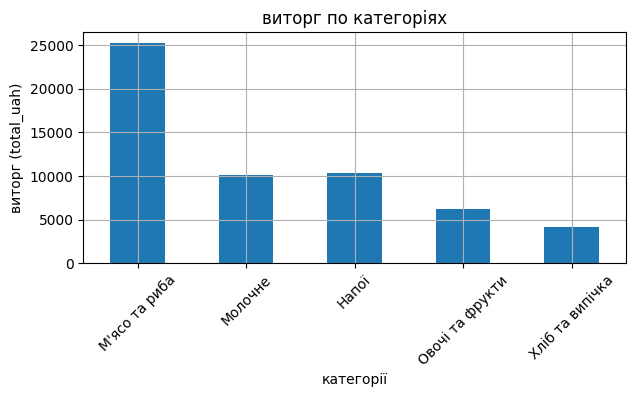

In [88]:
fig = plt.figure(figsize=(7, 3))
# df.category.value_counts().plot(kind='bar')
# df.groupby('category')['total_uah'].sum().bar()
df.groupby('category')['total_uah'].sum().plot(kind='bar')
plt.title("виторг по категоріях")
plt.xlabel("категорії")
plt.ylabel("виторг (total_uah)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

2. Горизонтальна стовпчаста - топ-10 товарів за виторгом.

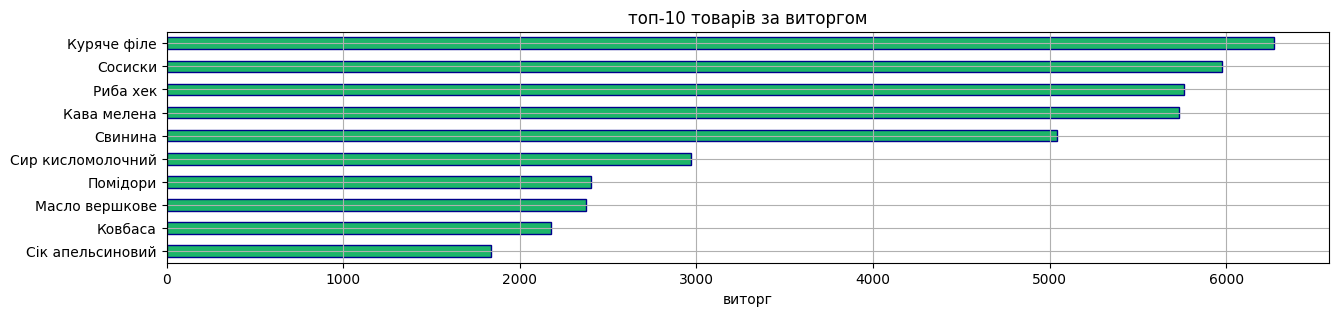

In [89]:
fig = plt.figure(figsize=(15, 3))

# top10_revenue = df.groupby('product')['total_uah'].sum().sort_values(ascending=False)[:10]
top10_revenue = (
    df.groupby('product')['total_uah']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

top10_revenue.plot(
    kind='barh',
    color='#1db569',
    edgecolor='darkblue'

)

plt.title('топ-10 товарів за виторгом')
plt.xlabel('виторг')
plt.ylabel('')

plt.grid()

plt.show()

3. Кругова діаграма - розподіл способів оплати.

In [90]:
df.payment.value_counts()

,count
payment,
Картка,157
Готівка,104
Телефон,39


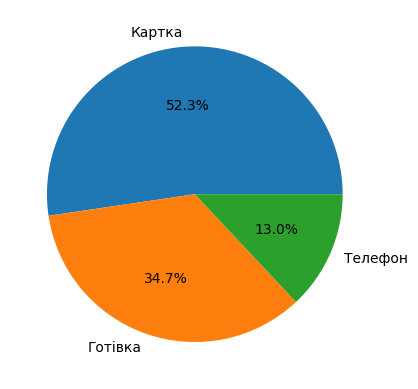

In [91]:
payment_count = df.payment.value_counts()
plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
plt.show()

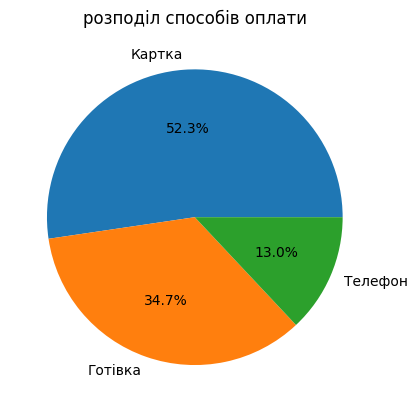

In [92]:
fig, ax = plt.subplots()
payment_count = df.payment.value_counts()
ax.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
ax.set_title('розподіл способів оплати')
plt.show()

4. Лінійний графік - виторг по днях березня.

<Axes: xlabel='day'>

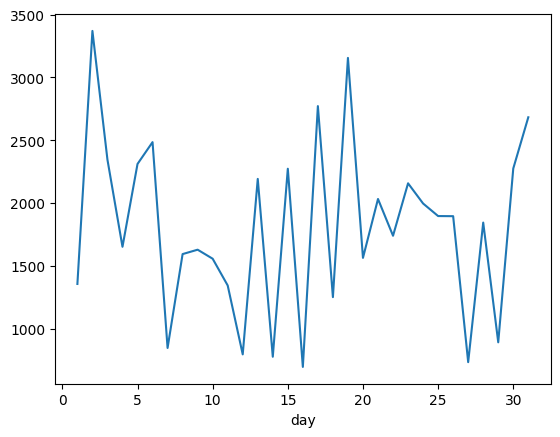

In [93]:
df.groupby('day')['total_uah'].sum().plot(kind='line')

In [95]:
df.groupby(['day', 'category'])['total_uah'].sum().head(10)

day  category       
1    Молочне             165
     Напої               756
     Овочі та фрукти     434
2    М'ясо та риба      2209
     Молочне             255
     Напої               375
     Овочі та фрукти     472
     Хліб та випічка      60
3    М'ясо та риба      1580
     Молочне             180
Name: total_uah, dtype: int64

In [96]:
df.groupby(['day', 'category'])['total_uah'].sum().unstack().head()

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка
day,,,,,
1,NaN,165.0,756.0,434.0,NaN
2,2209.0,255.0,375.0,472.0,60.0
3,1580.0,180.0,461.0,60.0,64.0
4,1320.0,114.0,162.0,NaN,55.0
5,630.0,305.0,811.0,175.0,390.0


<Axes: xlabel='day'>

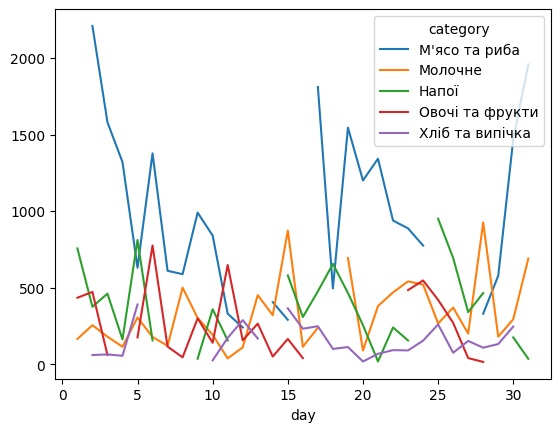

In [97]:
df.groupby(['day', 'category'])['total_uah'].sum().unstack().plot(kind='line')

In [98]:
pivot = df.groupby(['day', 'category'])['total_uah'].sum().unstack()
pivot['total_sum_day'] = pivot.sum(axis=1)
pivot.loc['total_sum_category'] = pivot.sum(axis=0)
pivot.tail(5)


category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка,total_sum_day
day,,,,,,
28,330.0,926.0,465.0,15.0,108.0,1844.0
29,578.0,180.0,NaN,NaN,132.0,890.0
30,1470.0,294.0,175.0,90.0,246.0,2275.0
31,1958.0,690.0,35.0,NaN,NaN,2683.0
total_sum_category,25223.0,10075.0,10389.0,6270.0,4134.0,56091.0


In [99]:
pd.pivot_table(
    df.head(),
    values='total_uah',
    index='day',
    columns='category',
    aggfunc='sum',
    margins=True,
    margins_name='total_sum'
)

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка,total_sum
day,,,,,,
1,NaN,NaN,NaN,45.0,NaN,45
2,360.0,NaN,NaN,NaN,NaN,360
9,NaN,150.0,NaN,NaN,NaN,150
13,NaN,NaN,465.0,NaN,NaN,465
17,NaN,NaN,NaN,NaN,72.0,72
total_sum,360.0,150.0,465.0,45.0,72.0,1092


5. Гістограма - розподіл customer_age.

In [100]:
df.customer_age.value_counts()

,count
customer_age,
28,10
32,10
37,10
58,9
20,9
25,9
19,8
46,8
29,8


[22. 14. 25. 20. 21. 24. 17. 21. 17. 22. 23. 20. 18. 16. 20.]


np.float64(20.0)

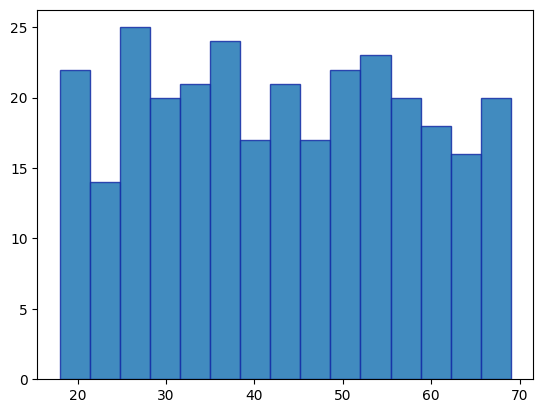

In [101]:
counts, bins, patches = plt.hist(
    df['customer_age'],
    bins=15,
    # color="",
    edgecolor="#162ea6",
    alpha=0.85
)

print(counts)
# print(bins)
# print(patches)
mean_counts = counts.mean()
mean_counts

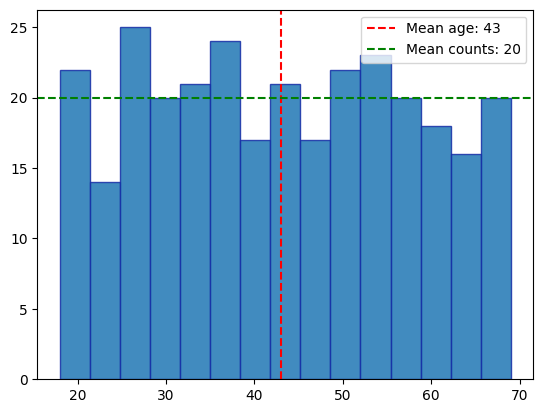

In [102]:
counts, bins, patches = plt.hist(
    df['customer_age'],
    bins=15,
    # color="",
    edgecolor="#162ea6",
    alpha=0.85
)

# vertical line - red
plt.axvline(
    df['customer_age'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean age: {df['customer_age'].mean():.0f}"
)

# horizont line - green
plt.axhline(
    counts.mean(),
    color='green',
    linestyle='--',
    label=f"Mean counts: {counts.mean():.0f}"
)

plt.legend()
plt.show()

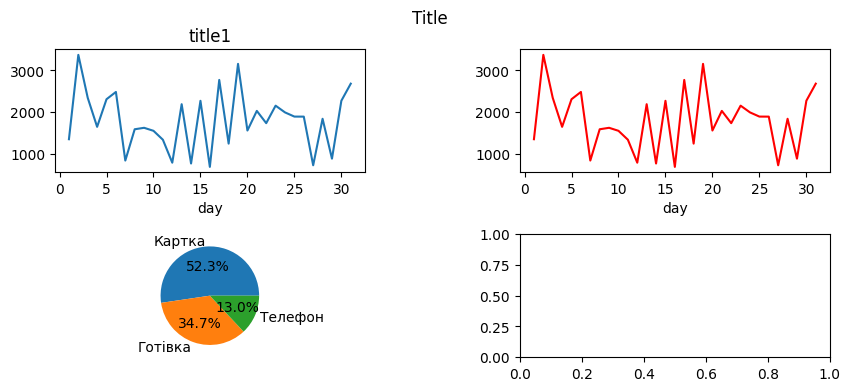

In [103]:
# plt.figure(figsize=(8, 3))
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Title")
plt.subplots_adjust(hspace=0.5, wspace=0.5)


ax1 = axes[0, 0]
ax1.set_title("title1")
ax1.set_xlabel("bins age")
df.groupby('day')['total_uah'].sum().plot(kind='line', ax=ax1)

ax2 = axes[0, 1]
df.groupby('day')['total_uah'].sum().plot(kind='line', color="red", ax=ax2)

ax3 = axes[1, 0]
payment_count = df.payment.value_counts()
ax3.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')

plt.savefig('figure.png')
plt.show()


## Conclusion

1. **Revenue by category.**   
"Meat & fish" is the clear leader at  approx 25,200 UAH — 45% of total revenue (56,091 UAH), almost 2.5x more than "Beverages" and "Dairy" (approx 10,000–10,400 UAH each). "Bread & pastries" is the smallest category (~4,100 UAH, 7%).  

2. **Top 10 products.**   
The top five — Chicken fillet, Sausages, Hake fish, Ground coffee, Pork — each bring in 5,000–6,000 UAH and make up most of the meat/fish category plus coffee from beverages. Together, the top 10 products account for roughly 70% of total revenue — a high concentration in a small number of items.   

3. **Payment methods.**   
Card — 157 (52%), Cash — 104 (35%), Phone — 39 (13%). Card clearly dominates; phone payment is the least used.  

4. **Revenue by day in March**.   
No clear trend — revenue fluctuates with peaks (day 2 ~3,370 UAH, days 30–31 ~2,300–2,700 UAH) and dips (day 29 ~890 UAH). This looks like typical irregular retail activity rather than steady growth or decline over the month.  

5. **Customer age**.   
Ages are spread broadly from 18 to 69 with no strong skew. Slightly higher density around 28–37 and 50–63, but overall the customer base is fairly mixed in age, with no single dominant segment.  

**Bottom line:** most revenue comes from the meat/fish category and a small set of top products, card payments dominate, daily revenue is unstable with no seasonal pattern, and the customer base spans a wide age range.

## Block 6 – Final Conclusions

**Most profitable category **  
- Meat & fish leads with  approx 25,223 UAH (45% of total revenue, 56,091 UAH) — almost 2.5x more than the next categories (Beverages  approx 10,389, Dairy  approx 10,075).

**Peak trading hours **  
Midday is busiest: 14:00 (44 transactions) and 13:00 (41) are the peak hours, with a secondary wave at 11:00–12:00 (30 each) and 16:00 (32). Quietest hours are early morning (8:00, 7) and late evening (19:00, 10).  

**Dominant payment method**   
Card — 157 transactions (52.3%), Cash — 104 (34.7%), Phone — 39 (13%). Card payments clearly dominate.  
**"Peak" sales days**  
By weekday, Sunday (55) and Saturday (51) see the most transactions, vs. 33–48 on weekdays. By calendar day, there are local spikes (e.g. days 2, 30, 31) and dips (e.g. day 29), but no steady upward or downward trend across the month.  
**Typical customer (age, purchases, payment)** Middle-aged (30–50, the largest group: 120/300), with the highest average check (~196 UAH) and the highest share of "big" purchases (>300 UAH) at 23.3%. Mostly buys meat/fish and beverages (the top revenue categories) and pays by card.